In [32]:
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [3]:
df = pd.read_csv('snsdata.csv')
df.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [4]:
X = df.drop(columns=['gradyear', 'gender', 'age', 'friends'])
X.shape

(30000, 36)

In [5]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

round(X_norm[0][0], 2)

np.float64(-0.33)

In [6]:
km = KMeans(n_clusters=9, random_state=42)
km.fit(X_norm)

km.inertia_

856276.6962467814

In [10]:
y = km.predict(X_norm)
y = pd.DataFrame(y, columns=['class'])
y.value_counts()

class
1        19599
2         4284
0         2201
4          941
3          902
5          851
8          754
7          467
6            1
Name: count, dtype: int64

<Axes: xlabel='cluster', ylabel='inertia'>

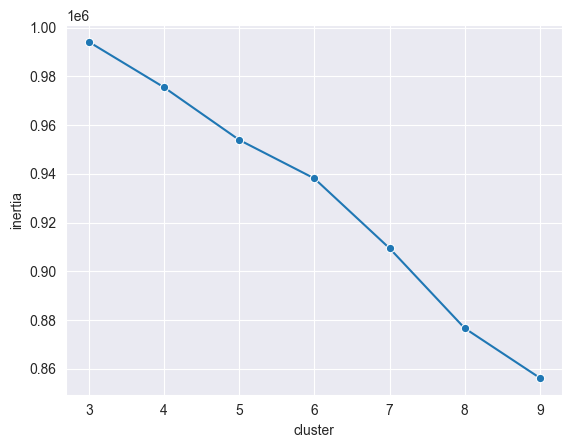

In [12]:
def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    inertia = k_means.inertia_
    return inertia

res = {"inertia": [], "cluster": []}

for cluster_num in range(3, 10):
    res["inertia"].append(get_inertia(cluster_num, X_norm))
    res["cluster"].append(cluster_num)

res_df = pd.DataFrame(res)

sns.set_style("darkgrid")
sns.lineplot(data=res_df, x="cluster", y="inertia", marker= "o")

<Axes: xlabel='cluster', ylabel='silhouette'>

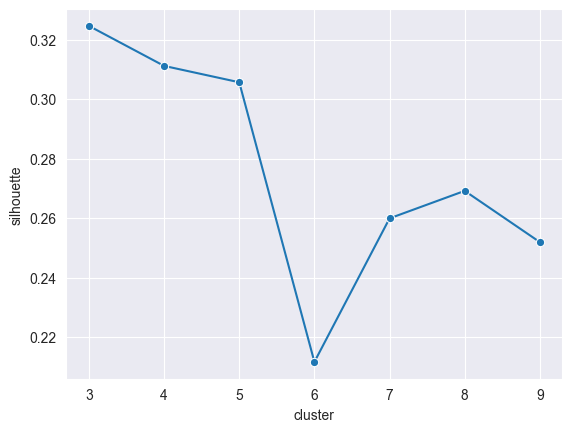

In [15]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.predict(X))
    return silhouette

silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(3, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X_norm))
    silhouette_res["cluster"].append(cluster_num)

silhouette_df = pd.DataFrame(silhouette_res)

sns.set_style("darkgrid")
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [16]:
k_means =  KMeans(n_clusters=3, random_state=42)
k_means.fit(X_norm)

y = k_means.predict(X_norm)
X['class'] = y

In [31]:
cluster_means = X.groupby('class').mean()
top_keywords = []
for cluster_label, row in cluster_means.iterrows():
    top10 = row.sort_values(ascending=False).head(10).index.tolist()
    top_keywords.append(set(top10))

res = top_keywords[0]
for top10 in top_keywords[1:]:
    res = res.intersection(top10)
res

{'dance', 'god', 'hair', 'music'}

In [34]:
em = GaussianMixture(n_components=3, random_state=42)
em.fit(X_norm)

y = em.predict(X_norm)
y = pd.DataFrame(y, columns=['class'])
y.value_counts()

class
0        20670
2         6456
1         2874
Name: count, dtype: int64